In [1]:
import fsspec

fs_osn = fsspec.filesystem(
    "s3",
    profile="ocean_emulator_write",  ## This is the profile name you configured above.
)

In [2]:
fs_osn.ls("emulators/sd5313/Samudra")

['emulators/sd5313/Samudra/OM4',
 'emulators/sd5313/Samudra/OM4_means',
 'emulators/sd5313/Samudra/OM4_stds']

#### Data check

In [2]:
mapper = fs_osn.get_mapper("emulators/jbusecke/ocean-emulators/CM4_5daily_v0.4.0.zarr")

In [3]:
import xarray as xr

ds = xr.open_zarr(mapper, consolidated=True)
ds

<xarray.Dataset>
Dimensions:         (y: 180, x: 360, lev: 19, time: 14600, y_b: 181, x_b: 361)
Coordinates:
    areacello       (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz              (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
  * lev             (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    ocean_fraction  (lev, y, x) float64 dask.array<chunksize=(5, 90, 180), meta=np.ndarray>
  * time            (time) object 0151-01-06 00:00:00 ... 0351-01-01 00:00:00
    wetmask         (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x               (x) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
Dimensions without coordinates: y_b, x_b
Data variables:
    hfds            (time, y, x) float32 dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    lat_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    lon_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    so              (time, lev, y, x) float32 dask.array<chunksize=(10, 1, 180, 360), meta=np.ndarray>
    tauuo           (time, y, x) float32 dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    tauvo           (time, y, x) float32 dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    thetao          (time, lev, y, x) float32 dask.array<chunksize=(10, 1, 180, 360), meta=np.ndarray>
    uo              (time, lev, y, x) float32 dask.array<chunksize=(10, 1, 180, 360), meta=np.ndarray>
    vo              (time, lev, y, x) float32 dask.array<chunksize=(10, 1, 180, 360), meta=np.ndarray>
    zos             (time, y, x) float32 dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [ ]:
# check data size
print("Total data size of CM4: ", ds.nbytes / 1e9, "GB")

In [14]:
import cftime

# Example DatetimeNoLeap object
no_leap_date = cftime.DatetimeNoLeap(150, 3, 29, 12, 0, 0)  # Replace with your own date

# Convert to DatetimeJulian
julian_date = cftime.DatetimeJulian(
    no_leap_date.year,
    no_leap_date.month,
    no_leap_date.day,
    no_leap_date.hour,
    no_leap_date.minute,
    no_leap_date.second,
)

julian_date

cftime.DatetimeJulian(150, 3, 29, 12, 0, 0, 0, has_year_zero=False)

In [4]:
ds.thetao.time.values

array([cftime.DatetimeNoLeap(151, 1, 6, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(151, 1, 11, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(151, 1, 16, 0, 0, 0, 0, has_year_zero=True),
       ...,
       cftime.DatetimeNoLeap(350, 12, 22, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(350, 12, 27, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(351, 1, 1, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)

In [9]:
data2.time.values

array([cftime.DatetimeJulian(1958, 1, 3, 12, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(1958, 1, 8, 12, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(1958, 1, 13, 12, 0, 0, 0, has_year_zero=False),
       ...,
       cftime.DatetimeJulian(2022, 12, 19, 12, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2022, 12, 24, 12, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2022, 12, 29, 12, 0, 0, 0, has_year_zero=False)],
      dtype=object)

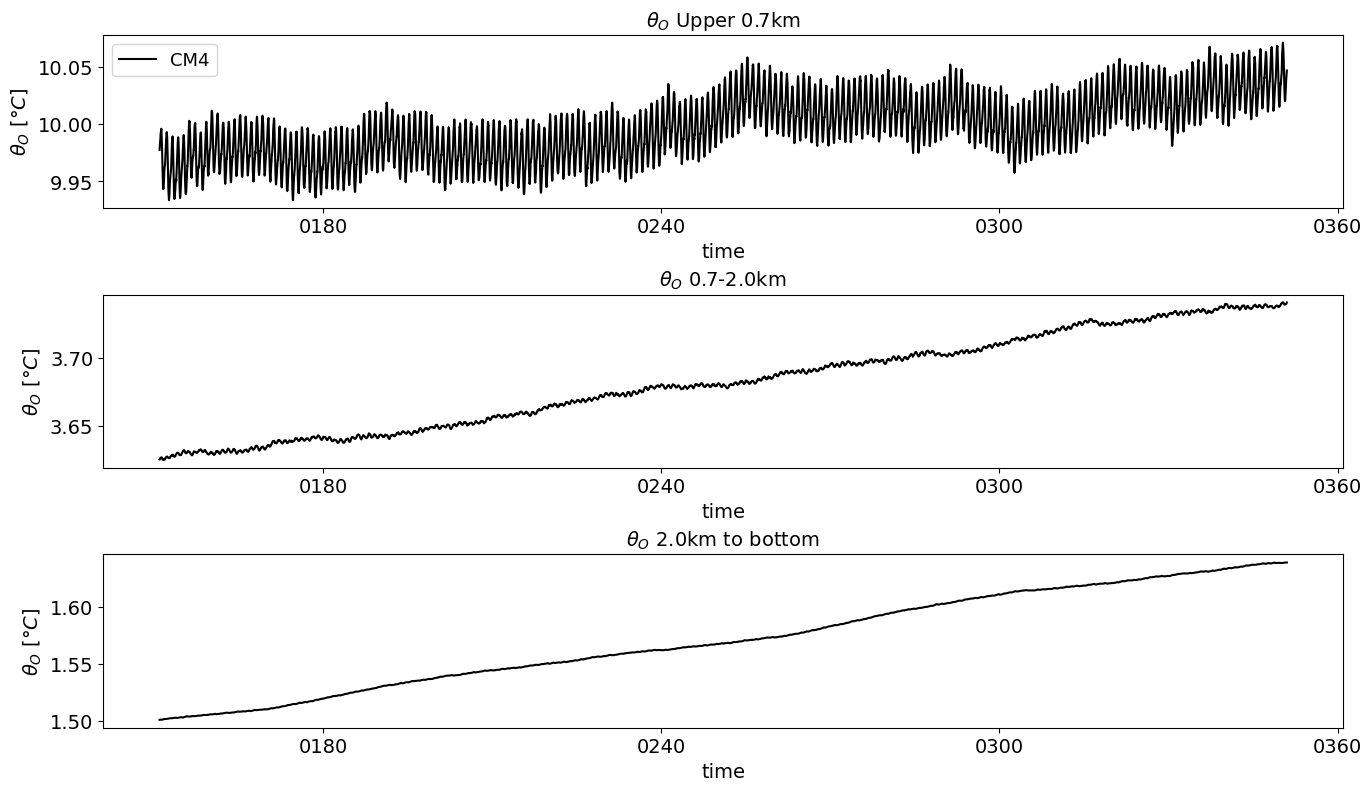

CPU times: user 4min 58s, sys: 38.8 s, total: 5min 36s
Wall time: 6min 1s


In [10]:
%%time
# All Sets - Depth - Thetao
import numpy as np
import matplotlib.pyplot as plt

level_slices = [slice(None, 700), slice(700, 2000), slice(2000, None)]
# level_slices = [slice(None, 300), slice(300, 600), slice(600,)]
titles = [
    r"$\theta_O$ Upper 0.7km",
    r"$\theta_O$ 0.7-2.0km",
    r"$\theta_O$ 2.0km to bottom",
]

data = ds
data2

ds_input = xr.open_zarr(
    os.path.join("/mnt/home/sd5313/data/Ocean", "OM4_5daily_v0.2.1.zarr")
)
ds_full_groundtruth = ds_input.astype("float32")
data2 = ds_full_groundtruth

plt.rcdefaults()
plt.rcParams.update({"font.size": 14})
fig, axs = plt.subplots(
    3, 1, figsize=(16, 9), gridspec_kw={"wspace": 0.25, "hspace": 0.5}
)

for i, lev_slice in enumerate(level_slices):
    thetao = (
        (data["thetao"].sel(lev=lev_slice))
        .weighted(data["areacello"] * data["dz"])
        .mean(["x", "y", "lev"])
    )
    thetao = thetao.rename(r"$\theta_O$")
    thetao = thetao.assign_attrs(units=r"$\degree C$")
    thetao.plot(ax=axs[i], label="CM4", color="k")

    #     thetao = (data2['thetao'].sel(lev=lev_slice)).weighted(data2['areacello'] * data2['dz']).mean(['x', 'y', 'lev'])
    #     thetao = thetao.rename(r'$\theta_O$')
    #     thetao = thetao.assign_attrs(units=r'$\degree C$')
    #     thetao.plot(ax=axs[i], label='OM4', color='red')

    axs[i].set_title(titles[i], fontsize=14)
    if i == 0:
        axs[i].legend(fontsize=13)

plt.show()

Weighted Tests

In [1]:
import xarray as xr

In [10]:
# Create a dataset
ds = xr.Dataset(
    {
        "temperature": (["x", "y"], [[2, 2], [2, 2]]),
        "precipitation": (["x", "y"], [[0, 1], [2, 3]]),
    },
    coords={"x": [0, 1], "y": [0, 1]},
)
vol = xr.DataArray([[3, 2], [3, 2]], dims=["x", "y"], coords={"x": [0, 1], "y": [0, 1]})

In [17]:
ds.temperature.weighted(vol).mean()

<xarray.DataArray 'temperature' ()>
array(2.)

In [23]:
((ds.temperature) * (vol / vol.sum())).sum()

<xarray.DataArray ()>
array(2.)